In [1]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import pandas as pd
from utils.graph import *
from metrics.graph import compare_dags
from utils.plotting import *

In [2]:
import pickle

subset = 'toyLarge'
# subset = 'toysmall'

with open(f'old_results/ea_ii/{subset}.pkl', 'rb') as f:
    results_ea = pickle.load(f)

with open(f'old_results/ges/{subset}.pkl', 'rb') as f:
    ges_results = pickle.load(f)

with open(f'old_results/hc/{subset}.pkl', 'rb') as f:
    hc_results = pickle.load(f)

results = results_ea

## DAG

In [3]:
def get_edges_from_digraph(cpdag: nx.DiGraph):
    """
    Split a CPDAG stored as a DiGraph (where undirected edges are encoded
    as u->v and v->u) into:

    directed:   {(u, v)}
    undirected: {{u, v}} represented once as (min(u,v), max(u,v))
    """
    directed = set()
    undirected = set()

    edges = set(cpdag.edges())

    for u, v in edges:
        # undirected edge (both directions present)
        if (v, u) in edges:
            # only record once
            if (v, u) not in undirected:
                undirected.add((u, v))
        else:
            directed.add((u, v))

    return directed, undirected


In [4]:
def dag_to_cpdag_pgmpy(dag: nx.DiGraph) -> tuple[nx.DiGraph, nx.Graph]: 
    dag = DAG(dag.edges())
    cpdag = dag.to_pdag()  # CPDAG/PDAG

    directed = cpdag.directed_edges
    undirected = cpdag.undirected_edges
    # print("directed:", directed)
    # print("undirected:", undirected)
    return directed, undirected

### Plotting 

In [5]:
cpdag = dag_to_cpdag(results[0].learned_dags[0])

In [6]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Tuple, Dict, Any

import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_agraph import graphviz_layout


@dataclass(frozen=True)
class CPDAG:
    directed: nx.DiGraph
    undirected: nx.Graph


def cpdag_to_multidigraph(cpdag: CPDAG) -> nx.MultiDiGraph:
    """
    Pack a CPDAG into a single MultiDiGraph with edge attribute `kind` in
    {"directed","undirected"}.

    Note: we still draw in two passes to style arrows properly.
    """
    M = nx.MultiDiGraph()

    nodes = set(cpdag.directed.nodes()) | set(cpdag.undirected.nodes())
    M.add_nodes_from(nodes)

    for u, v in cpdag.undirected.edges():
        # store undirected as a single edge with kind="undirected"
        # (direction is irrelevant; we draw it without arrows)
        M.add_edge(u, v, kind="undirected")

    for u, v in cpdag.directed.edges():
        M.add_edge(u, v, kind="directed")

    return M


In [9]:

true_cpdag = dag_to_cpdag(results[0].true_dags[0])
learned_cpdag = dag_to_cpdag(results[0].learned_dags[0])

(<Figure size 1200x1000 with 1 Axes>,
 {'correct': {(0, 4),
   (0, 15),
   (0, 19),
   (1, 3),
   (1, 9),
   (1, 11),
   (2, 3),
   (2, 9),
   (3, 7),
   (3, 12),
   (3, 14),
   (4, 0),
   (4, 5),
   (4, 17),
   (4, 20),
   (5, 4),
   (5, 6),
   (6, 5),
   (6, 7),
   (6, 8),
   (8, 6),
   (8, 22),
   (8, 28),
   (9, 11),
   (11, 29),
   (13, 15),
   (14, 27),
   (15, 16),
   (16, 20),
   (16, 24),
   (17, 4),
   (18, 21),
   (18, 29),
   (19, 0),
   (21, 23),
   (22, 8),
   (28, 8)},
  'wrong_dir': {(0, 4),
   (0, 19),
   (3, 1),
   (3, 2),
   (4, 0),
   (4, 5),
   (4, 17),
   (5, 4),
   (5, 6),
   (6, 5),
   (6, 8),
   (8, 6),
   (8, 22),
   (8, 28),
   (12, 10),
   (14, 3),
   (17, 4),
   (18, 13),
   (19, 0),
   (22, 8),
   (26, 23),
   (27, 14),
   (28, 8)},
  'extra': {(3, 10),
   (3, 18),
   (5, 18),
   (5, 26),
   (8, 25),
   (9, 12),
   (10, 13),
   (11, 18),
   (12, 7),
   (15, 23),
   (16, 26),
   (17, 23),
   (19, 26),
   (21, 26),
   (25, 8),
   (29, 12),
   (29, 13)},
  'm

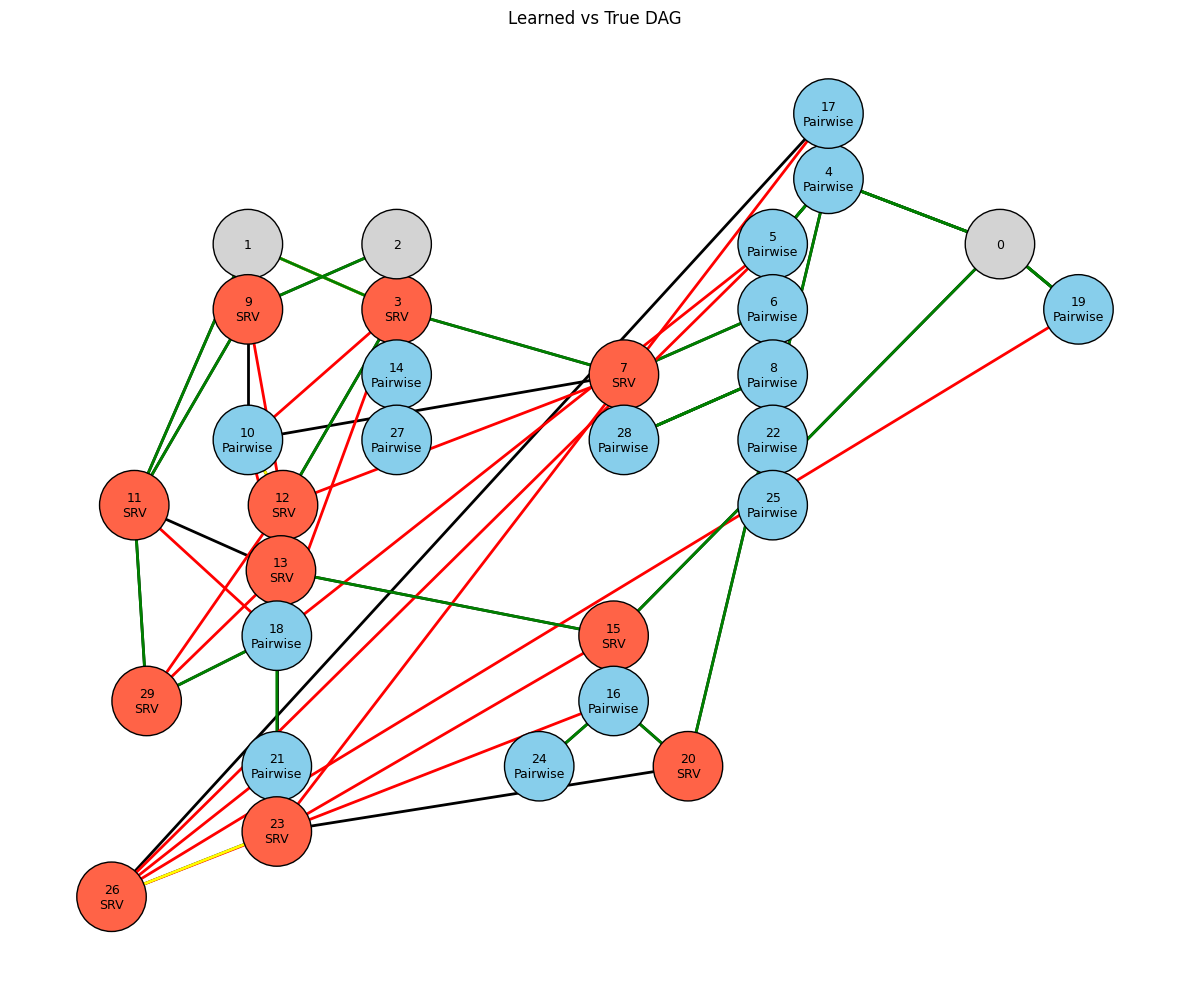

In [11]:
compare_dags_with_labels(
    true_cpdag, learned_cpdag, metadata=results[0].metadata[0])